# Многослойные и шумные автокодировщики

**Задание:**
- разобраться с тем, как работает шумный (denoising) автокодировщик и что содержится в его латентном представлении данных;
- обучить шумный автокодировщик:
  - добавить ко входным данным нормальный шум;
  - сделать отражение части изображения;
  - отрисовать карты активаций нейронов первого слоя.

**План:**
1. Теория: обычный и шумный автокодировщик.
2. Многослойный полносвязный автокодировщик `784 → 512 → 256 → 32 → 256 → 512 → 784` на MNIST — базовая модель.
3. Шумный автокодировщик той же архитектуры: вход искажается гауссовским шумом и зеркальным отражением части изображения, цель — чистое изображение.
4. Сравнение моделей: качество очистки, устойчивость латентного кода к искажениям, что «знает» латентный код (t-SNE, линейный классификатор), интерполяция в латентном пространстве.
5. Карты активаций нейронов первого слоя: веса нейронов как изображения 28×28 и отклик нейронов на конкретные входы.

## 1. Как работает шумный автокодировщик

**Обычный автокодировщик** состоит из энкодера $z = f_\theta(x)$ и декодера $\hat x = g_\phi(z)$ и минимизирует ошибку реконструкции $\lVert x - g_\phi(f_\theta(x))\rVert^2$. Если латентный слой достаточно широкий, сеть может выучить почти тождественное отображение, не извлекая полезной структуры данных; узкое «бутылочное горлышко» мешает этому, но не гарантирует, что признаки будут осмысленными.

**Шумный (denoising) автокодировщик** (Vincent et al., 2008) меняет постановку задачи: на вход подаётся *испорченная* версия $\tilde x \sim C(\tilde x \mid x)$, а восстанавливать нужно *чистое* $x$:
$$\mathcal L = \mathbb E_{x}\,\mathbb E_{\tilde x \sim C(\cdot\mid x)} \lVert x - g_\phi(f_\theta(\tilde x))\rVert^2 .$$
Тождественное отображение перестаёт быть решением: чтобы убрать искажение, сеть должна знать, *как выглядят настоящие данные*, т.е. выучить многообразие, на котором лежат цифры, и уметь «проецировать» на него испорченные точки. Геометрически: искажение уводит точку $x$ с многообразия данных, а автокодировщик учится возвращать её обратно (оптимальный денойзер при малом гауссовском шуме связан со score-функцией $\nabla_x \log p(x)$ — та же идея лежит в основе диффузионных моделей).

**Что в латентном представлении.** Энкодер шумного АЕ должен отображать и $x$, и все его искажённые версии $\tilde x$ в близкие коды, из которых декодер восстановит одно и то же чистое $x$. Поэтому латентный код:
- кодирует **существенные** характеристики цифры (класс, наклон, толщину и форму штрихов);
- **инвариантен** к нерелевантным искажениям (пиксельный шум, локальная порча части изображения);
- первые слои превращаются в детекторы протяжённых штрихов, а не отдельных пикселей — это увидим на картах весов.

**Искажения в этой работе:**
1. **нормальный шум**: $\tilde x = \mathrm{clip}(x + \varepsilon, 0, 1)$, $\varepsilon \sim \mathcal N(0, \sigma^2)$, $\sigma = 0.5$;
2. **отражение части изображения**: выбирается случайный прямоугольный фрагмент (от 1/3 до 1/2 стороны) и зеркально отражается по горизонтали или вертикали внутри себя.

Искажения генерируются заново на каждом батче, так что сеть не видит одно и то же испорченное изображение дважды.

## 2. Импорты, данные

In [1]:
import time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(torch.__version__, device)

tfm = transforms.ToTensor()
train_ds = torchvision.datasets.MNIST('./data', train=True, download=True, transform=tfm)
test_ds = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tfm)

# MNIST целиком помещается в память GPU — так обучение идёт в разы быстрее, чем через DataLoader
X_train = train_ds.data.float().div(255).view(-1, 784).to(device); y_train = train_ds.targets.to(device)
X_test = test_ds.data.float().div(255).view(-1, 784).to(device); y_test = test_ds.targets.to(device)
print(X_train.shape, X_test.shape)

2.7.0+cu126 cuda
torch.Size([60000, 784]) torch.Size([10000, 784])


### 2.1 Искажения: нормальный шум и отражение части изображения

In [2]:
NOISE_STD = 0.5

def add_gaussian_noise(x, std=NOISE_STD):
    return (x + std * torch.randn_like(x)).clamp(0, 1)

def reflect_patch(x, min_frac=1/3, max_frac=1/2):
    # Для каждого изображения: случайный прямоугольник, отражённый внутри себя по горизонтали или вертикали
    B = x.shape[0]
    img = x.view(B, 28, 28).clone()
    h = torch.randint(int(28 * min_frac), int(28 * max_frac) + 1, (B,))
    w = torch.randint(int(28 * min_frac), int(28 * max_frac) + 1, (B,))
    top = (torch.rand(B) * (28 - h + 1)).long()
    left = (torch.rand(B) * (28 - w + 1)).long()
    horizontal = torch.rand(B) < 0.5
    # векторизованно: для каждого пикселя вычисляем, откуда брать значение
    r = torch.arange(28).view(1, 28, 1).expand(B, 28, 28)
    c = torch.arange(28).view(1, 1, 28).expand(B, 28, 28)
    T, L = top.view(B, 1, 1), left.view(B, 1, 1)
    H, W = h.view(B, 1, 1), w.view(B, 1, 1)
    inside = (r >= T) & (r < T + H) & (c >= L) & (c < L + W)
    hz = horizontal.view(B, 1, 1)
    src_r = torch.where(inside & ~hz, 2 * T + H - 1 - r, r)
    src_c = torch.where(inside & hz, 2 * L + W - 1 - c, c)
    idx = (src_r * 28 + src_c).view(B, -1).to(x.device)
    out = torch.gather(x.view(B, -1), 1, idx)
    return out, (top, left, h, w, horizontal)

def corrupt(x):
    x, _ = reflect_patch(x)
    return add_gaussian_noise(x)

# визуализация
torch.manual_seed(0)
xs = X_test[:8]
x_refl, (top, left, h, w, hz) = reflect_patch(xs)
x_noise = add_gaussian_noise(xs)
x_both = add_gaussian_noise(x_refl)
fig, axes = plt.subplots(4, 8, figsize=(12, 6.4))
for j in range(8):
    for i, (im, name) in enumerate([(xs, 'оригинал'), (x_noise, f'шум σ={NOISE_STD}'),
                                     (x_refl, 'отражение части'), (x_both, 'отражение + шум')]):
        ax = axes[i, j]; ax.imshow(im[j].view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1); ax.set_xticks([]); ax.set_yticks([])
        if j == 0: ax.set_ylabel(name, fontsize=10)
        if i == 2:
            ax.add_patch(plt.Rectangle((left[j] - .5, top[j] - .5), w[j], h[j], fill=False, ec='red', lw=1.2))
            ax.set_title('↔' if hz[j] else '↕', fontsize=10, color='red')
plt.suptitle('Искажения входа (красная рамка — отражённый фрагмент)'); plt.tight_layout(); plt.show()

<Figure size 1200x640 with 32 Axes>

## 3. Многослойный автокодировщик

Архитектура (полносвязная, симметричная):
```
энкодер: 784 → 512 → 256 → 32      (ReLU, латентный слой — линейный)
декодер: 32 → 256 → 512 → 784       (ReLU, на выходе sigmoid)
```
Полносвязная архитектура выбрана специально: у каждого нейрона первого слоя есть вектор весов длины 784, который можно нарисовать как картинку 28×28 и прямо увидеть, на какой паттерн во входе реагирует нейрон.

Обучаем две модели **одинаковой архитектуры и с одинаковыми гиперпараметрами**:
- `ae` — обычный автокодировщик: вход = чистое изображение;
- `dae` — шумный автокодировщик: вход = искажённое изображение (отражение + шум), цель = чистое.

Функция потерь — бинарная кросс-энтропия по пикселям (пиксели в $[0,1]$), оптимизатор Adam.

In [3]:
class MLPAutoencoder(nn.Module):
    def __init__(self, dims=(784, 512, 256, 32)):
        super().__init__()
        enc, dec = [], []
        for i in range(len(dims) - 1):
            enc += [nn.Linear(dims[i], dims[i + 1])] + ([nn.ReLU()] if i < len(dims) - 2 else [])
        rdims = dims[::-1]
        for i in range(len(rdims) - 1):
            dec += [nn.Linear(rdims[i], rdims[i + 1])] + ([nn.ReLU()] if i < len(rdims) - 2 else [])
        self.encoder = nn.Sequential(*enc)
        self.decoder = nn.Sequential(*dec)      # логиты; sigmoid применяется в loss / при выводе

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def reconstruct(self, x):
        return torch.sigmoid(self(x)[0])

    def first_layer(self, x):
        # активации нейронов первого скрытого слоя (после ReLU)
        return F.relu(self.encoder[0](x))

print(MLPAutoencoder())
print('params:', sum(p.numel() for p in MLPAutoencoder().parameters()))

MLPAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
  )
)
params: 1083696


In [4]:
EPOCHS, BS, LR = 30, 256, 1e-3

@torch.no_grad()
def evaluate(model, corrupt_fn=None, seed=123):
    # MSE восстановления чистого теста по (возможно искажённому) входу
    model.eval()
    g = torch.random.fork_rng(devices=[device] if device == 'cuda' else [])
    with g:
        torch.manual_seed(seed)
        errs = []
        for i in range(0, len(X_test), 2000):
            x = X_test[i:i + 2000]
            inp = corrupt_fn(x) if corrupt_fn else x
            errs.append(F.mse_loss(model.reconstruct(inp), x, reduction='sum').item())
    return sum(errs) / X_test.numel()

def train(model, corrupt_fn=None, epochs=EPOCHS, name=''):
    torch.manual_seed(SEED)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    hist = {'train': [], 'test_clean': [], 'test_corrupt': []}
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train), device=device)
        tot = 0.0
        for i in range(0, len(perm), BS):
            x = X_train[perm[i:i + BS]]
            inp = corrupt_fn(x) if corrupt_fn else x
            logits, _ = model(inp)
            loss = F.binary_cross_entropy_with_logits(logits, x, reduction='sum') / len(x)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(x)
        sched.step()
        hist['train'].append(tot / len(X_train))
        hist['test_clean'].append(evaluate(model))
        hist['test_corrupt'].append(evaluate(model, corrupt))
        if ep % 5 == 4 or ep == 0:
            print(f'[{name}] epoch {ep+1:2d}  train BCE {hist["train"][-1]:6.2f}  '
                  f'test MSE clean→clean {hist["test_clean"][-1]:.4f}  corrupt→clean {hist["test_corrupt"][-1]:.4f}')
    print(f'[{name}] {time.time()-t0:.0f}s')
    return hist

ae = MLPAutoencoder().to(device)
hist_ae = train(ae, None, name='AE ')
dae = MLPAutoencoder().to(device)
hist_dae = train(dae, corrupt, name='DAE')

[AE ] epoch  1  train BCE 184.01  test MSE clean→clean 0.0319  corrupt→clean 0.0661


[AE ] epoch  5  train BCE  80.24  test MSE clean→clean 0.0122  corrupt→clean 0.0926


[AE ] epoch 10  train BCE  68.25  test MSE clean→clean 0.0081  corrupt→clean 0.0977


[AE ] epoch 15  train BCE  64.31  test MSE clean→clean 0.0067  corrupt→clean 0.0991


[AE ] epoch 20  train BCE  62.49  test MSE clean→clean 0.0062  corrupt→clean 0.1012


...

[DAE] epoch 10  train BCE 122.45  test MSE clean→clean 0.0249  corrupt→clean 0.0308


[DAE] epoch 15  train BCE 117.08  test MSE clean→clean 0.0212  corrupt→clean 0.0284


[DAE] epoch 20  train BCE 114.21  test MSE clean→clean 0.0198  corrupt→clean 0.0273


[DAE] epoch 25  train BCE 112.78  test MSE clean→clean 0.0192  corrupt→clean 0.0268


[DAE] epoch 30  train BCE 112.36  test MSE clean→clean 0.0190  corrupt→clean 0.0267
[DAE] 18s


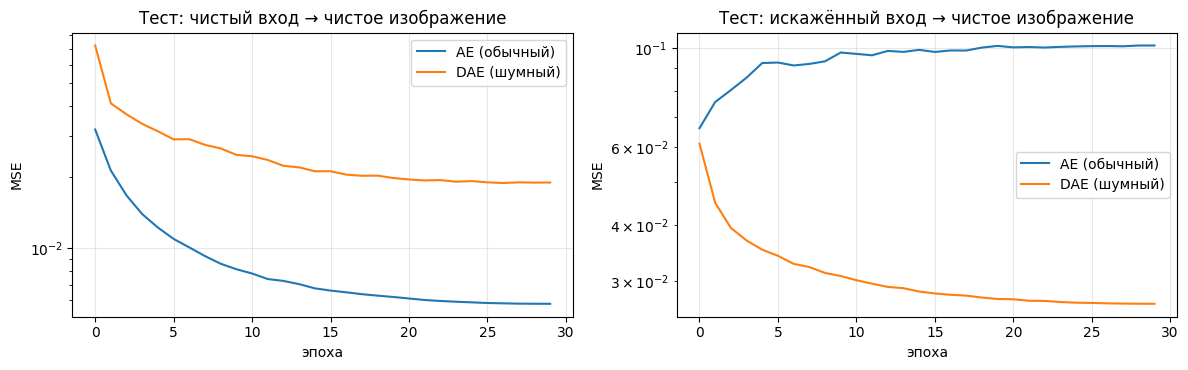

MSE на тесте                       AE      DAE
чистый вход                    0.0058   0.0190
только шум                     0.0882   0.0188
только отражение               0.0404   0.0268


отражение + шум                0.1014   0.0267


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for h, name in [(hist_ae, 'AE (обычный)'), (hist_dae, 'DAE (шумный)')]:
    axes[0].plot(h['test_clean'], label=name)
    axes[1].plot(h['test_corrupt'], label=name)
axes[0].set_title('Тест: чистый вход → чистое изображение'); axes[1].set_title('Тест: искажённый вход → чистое изображение')
for ax in axes: ax.set_xlabel('эпоха'); ax.set_ylabel('MSE'); ax.set_yscale('log'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

noise_only = lambda x: add_gaussian_noise(x)
refl_only = lambda x: reflect_patch(x)[0]
print(f'{"MSE на тесте":28s} {"AE":>8s} {"DAE":>8s}')
for name, fn in [('чистый вход', None), ('только шум', noise_only), ('только отражение', refl_only), ('отражение + шум', corrupt)]:
    print(f'{name:28s} {evaluate(ae, fn):8.4f} {evaluate(dae, fn):8.4f}')

Обычный автокодировщик заметно (примерно в 3 раза) точнее восстанавливает **чистые** изображения: именно этому он и учился, а DAE тратит часть ёмкости на подавление искажений и выдаёт более «сглаженные» цифры. На искажённом входе картина обратная. Ошибка обычного АЕ вырастает более чем в 15 раз: такой вход лежит далеко от обучающих данных, и декодер выдаёт мусор. Шумный АЕ восстанавливает искажённые изображения почти так же хорошо, как чистые. Гауссовский шум он убирает практически «бесплатно», а отражённый фрагмент — самое трудное искажение.

### 3.1 Примеры восстановления

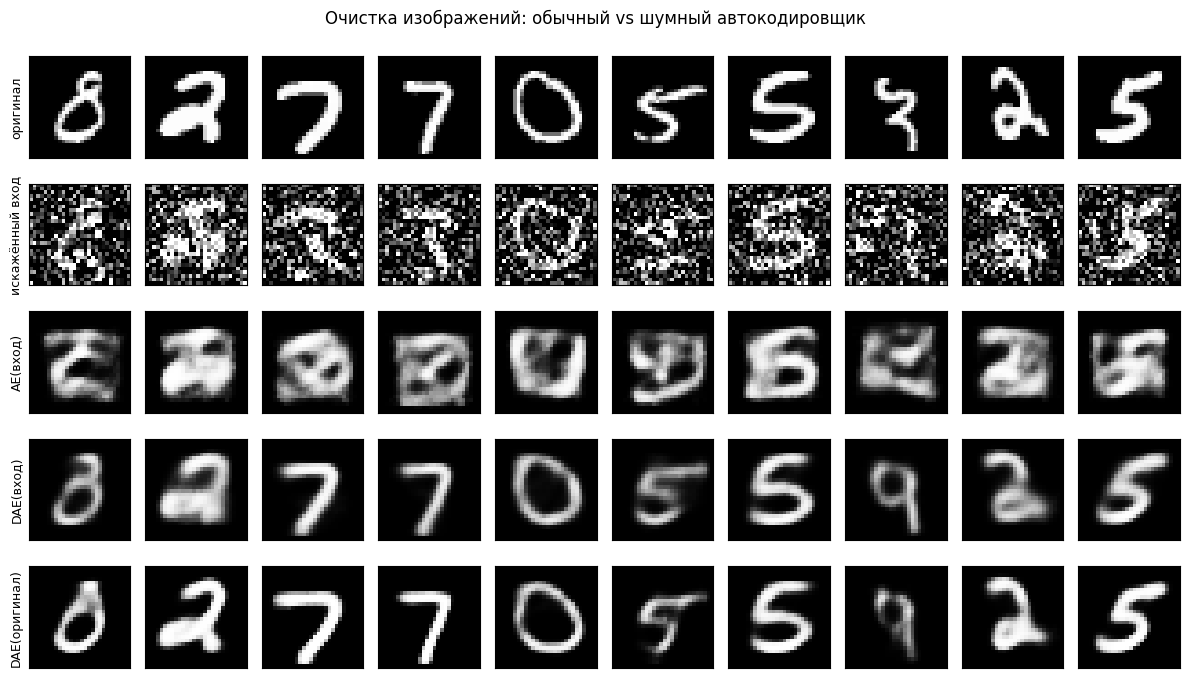

In [6]:
torch.manual_seed(7)
xs = X_test[torch.randperm(len(X_test), device=device)[:10]]
xc = corrupt(xs)
with torch.no_grad():
    rows = [(xs, 'оригинал'), (xc, 'искажённый вход'), (ae.reconstruct(xc), 'AE(вход)'), (dae.reconstruct(xc), 'DAE(вход)'),
            (dae.reconstruct(xs), 'DAE(оригинал)')]
fig, axes = plt.subplots(len(rows), 10, figsize=(12, 1.3 * len(rows) + 0.5))
for i, (im, name) in enumerate(rows):
    for j in range(10):
        ax = axes[i, j]; ax.imshow(im[j].view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1); ax.set_xticks([]); ax.set_yticks([])
    axes[i, 0].set_ylabel(name, fontsize=9)
plt.suptitle('Очистка изображений: обычный vs шумный автокодировщик'); plt.tight_layout(); plt.show()

Обычный AE на искажённом входе выдаёт размытые пятна: он никогда не видел такого шума, и его код уводит декодер в область, где нет правдоподобных цифр. Шумный AE убирает шум полностью и в большинстве случаев «достраивает» правильную форму цифры на месте отражённого фрагмента — для этого ему нужно понимать, какой должна быть цифра целиком, т.е. опираться на глобальную структуру, а не на локальные пиксели. Там, где отражение затронуло ключевую часть штриха, восстановление может превратить цифру в похожую (например, 4 ↔ 9) — информация на входе действительно неоднозначна.

## 4. Что содержится в латентном представлении

Исследуем 32-мерные латентные коды двух моделей с нескольких сторон.

### 4.1 Устойчивость кода к искажениям

Если энкодер инвариантен к искажениям, то коды $f(x)$ и $f(\tilde x)$ должны быть близки. Меряем относительное смещение $\lVert f(\tilde x) - f(x)\rVert / \lVert f(x)\rVert$ и косинусную близость. Нормировка на $\lVert f(x)\rVert$ нужна, потому что масштабы латентных пространств у двух моделей разные.

In [7]:
@torch.no_grad()
def encode(model, x):
    model.eval()
    return torch.cat([model.encoder(x[i:i + 5000]) for i in range(0, len(x), 5000)])

torch.manual_seed(0)
Xc_test = corrupt(X_test)
res = {}
for model, name in [(ae, 'AE'), (dae, 'DAE')]:
    z, zc = encode(model, X_test), encode(model, Xc_test)
    rel = ((zc - z).norm(dim=1) / z.norm(dim=1)).mean().item()
    cos = F.cosine_similarity(z, zc).mean().item()
    # насколько код искажённой картинки ближе к коду "своего" оригинала, чем к кодам других картинок:
    # ищем ближайший чистый код для каждого искажённого (по 2000 примеров)
    d = torch.cdist(zc[:2000], z[:2000])
    top1 = (d.argmin(1) == torch.arange(2000, device=device)).float().mean().item()
    res[name] = (z, zc)
    print(f'{name:4s} отн. смещение кода {rel:.3f} | cos(z, z̃) = {cos:.3f} | '
          f'ближайший чистый код = свой оригинал: {100*top1:.1f}%')

AE   отн. смещение кода 0.733 | cos(z, z̃) = 0.674 | ближайший чистый код = свой оригинал: 0.9%
DAE  отн. смещение кода 0.566 | cos(z, z̃) = 0.882 | ближайший чистый код = свой оригинал: 9.5%


Код шумного АЕ заметно меньше смещается при искажении входа (cos-близость ≈0.88 против ≈0.67): энкодер отображает испорченное изображение в окрестность кода чистого. Полной инвариантности нет. Искажение σ=0.5 очень сильное, и поиск «своего» оригинала по ближайшему коду среди 2000 срабатывает лишь в ~10% случаев. Но и это на порядок лучше, чем у обычного АЕ (~1%). Иными словами, DAE сохраняет в коде в первую очередь *класс и общую форму* цифры, а не индивидуальные детали конкретного экземпляра: их восстановить из такого шума уже нельзя.

### 4.2 Классы в латентном пространстве: линейный классификатор и t-SNE

Автокодировщики обучались **без меток**. Проверим, насколько линейно отделимы классы в латентных кодах: обучаем логистическую регрессию на кодах train и тестируем на кодах test — чистых и искажённых. Для сравнения — та же регрессия прямо по пикселям.

In [8]:
def probe(train_feat, test_sets, n_train=20000):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(train_feat[:n_train].cpu().numpy(), y_train[:n_train].cpu().numpy())
    return [clf.score(t.cpu().numpy(), y_test.cpu().numpy()) for t in test_sets]

torch.manual_seed(1)
Xc_train = corrupt(X_train[:20000])
print(f'{"признаки":24s} {"обучение на":14s} {"тест чистый":>12s} {"тест искаж.":>12s}')
acc = probe(X_train, [X_test, Xc_test]); print(f'{"пиксели (784)":24s} {"чистых":14s} {acc[0]:12.3f} {acc[1]:12.3f}')
for model, name in [(ae, 'AE'), (dae, 'DAE')]:
    z, zc = res[name]
    acc = probe(encode(model, X_train), [z, zc])
    print(f'{name + " латент (32)":24s} {"чистых":14s} {acc[0]:12.3f} {acc[1]:12.3f}')

признаки                 обучение на     тест чистый  тест искаж.


пиксели (784)            чистых                0.916        0.201


AE латент (32)           чистых                0.923        0.229


DAE латент (32)          чистых                0.930        0.589


Главный вывод из таблицы — в столбце «тест искажённый»: классификатор, обученный на кодах **чистых** изображений, продолжает работать на кодах искажённых изображений только у шумного АЕ. Это прямое следствие инвариантности кода: искажённая «7» кодируется туда же, где лежат чистые «7». У обычного АЕ и у пикселей точность на искажённых данных падает почти до случайного уровня (~20–23%), у DAE — остаётся ~59%. На чистых данных коды обеих моделей не хуже пикселей (≈92–93%), хотя имеют размерность 32 вместо 784.

Визуализируем 32-мерные латентные пространства через t-SNE (по 3000 тестовых изображений; метки только для раскраски).

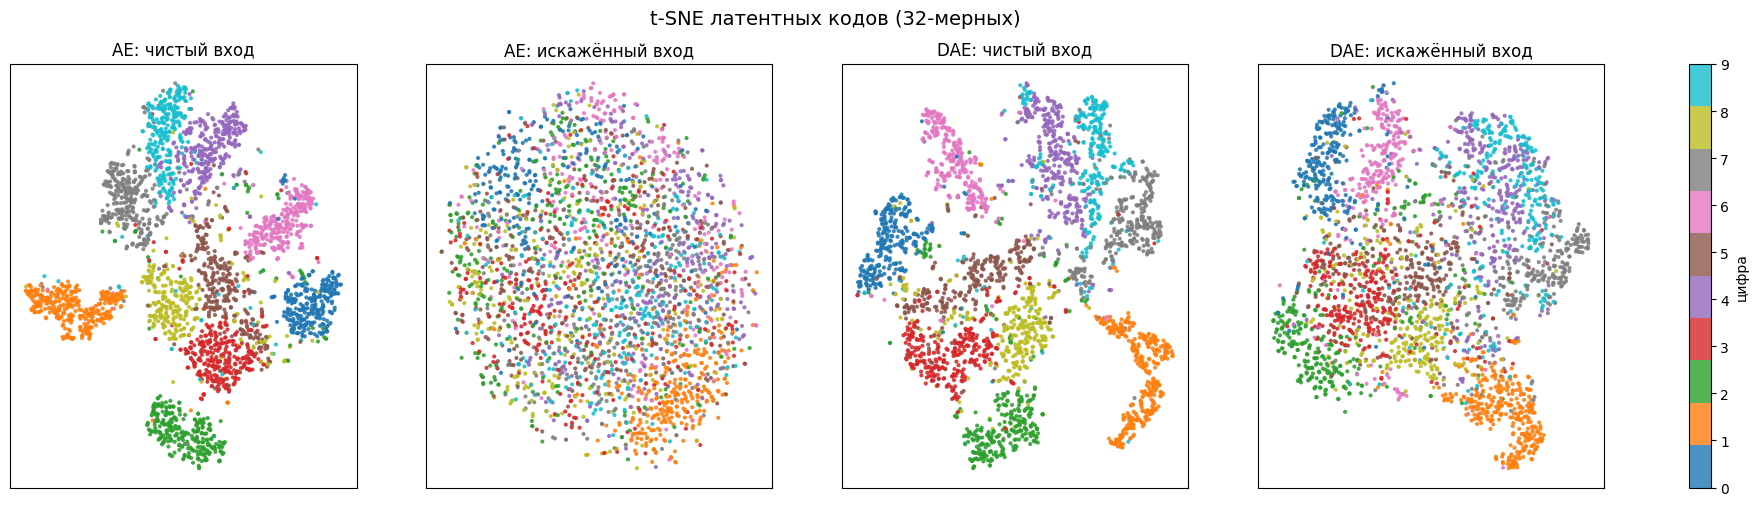

In [9]:
N = 3000
labels = y_test[:N].cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for k, (name, which, title) in enumerate([('AE', 0, 'AE: чистый вход'), ('AE', 1, 'AE: искажённый вход'),
                                           ('DAE', 0, 'DAE: чистый вход'), ('DAE', 1, 'DAE: искажённый вход')]):
    emb = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(res[name][which][:N].cpu().numpy())
    sc = axes[k].scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=4, alpha=0.8)
    axes[k].set_title(title); axes[k].set_xticks([]); axes[k].set_yticks([])
cbar = fig.colorbar(sc, ax=axes, ticks=range(10), fraction=0.015); cbar.set_label('цифра')
plt.suptitle('t-SNE латентных кодов (32-мерных)', fontsize=14); plt.show()

На чистом входе обе модели дают похожую картину: цифры образуют отдельные кластеры, хотя модели не видели меток — класс «вылезает» как самый существенный фактор изменчивости изображений. На искажённом входе кластеры обычного АЕ размываются и перемешиваются, а у шумного АЕ структура практически сохраняется.

Оговорка: t-SNE сохраняет только локальное соседство точек, расстояния между кластерами и их размеры интерпретировать нельзя.

### 4.3 Интерполяция в латентном пространстве

Ещё один способ понять, что кодирует латентное пространство: линейно проинтерполировать между кодами двух изображений и декодировать промежуточные точки. Если латентное пространство «гладкое», промежуточные изображения будут правдоподобными цифрами, плавно перетекающими друг в друга, а не просто наложением двух картинок.

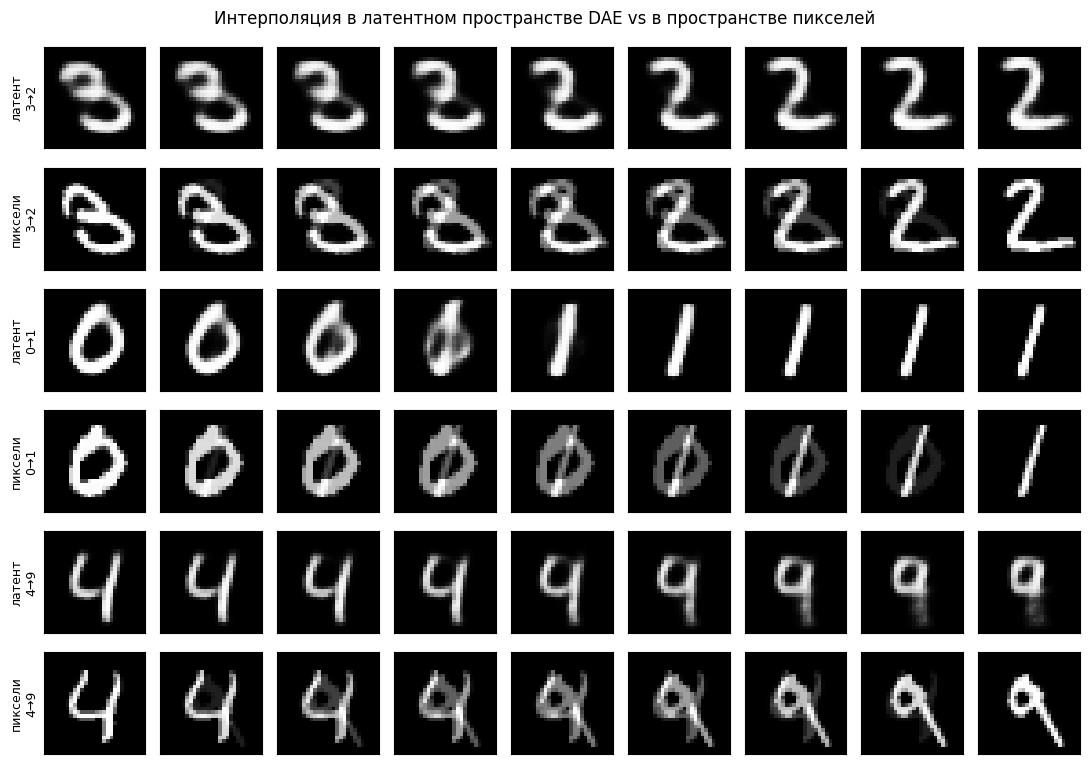

In [10]:
pairs = [(3, 2), (0, 1), (4, 9)]      # индексы в тестовой выборке будут подобраны по классам
def first_idx(c, k=0):
    return (y_test == c).nonzero()[k].item()

alphas = torch.linspace(0, 1, 9, device=device)
fig, axes = plt.subplots(2 * len(pairs), 9, figsize=(11, 2.6 * len(pairs)))
for p, (a, b) in enumerate(pairs):
    xa, xb = X_test[first_idx(a)], X_test[first_idx(b)]
    with torch.no_grad():
        za, zb = dae.encoder(xa[None]), dae.encoder(xb[None])
        lat = torch.sigmoid(dae.decoder(torch.stack([(1 - t) * za[0] + t * zb[0] for t in alphas])))
    pix = torch.stack([(1 - t) * xa + t * xb for t in alphas])
    for j in range(9):
        for r, im in [(2 * p, lat[j]), (2 * p + 1, pix[j])]:
            ax = axes[r, j]; ax.imshow(im.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1); ax.set_xticks([]); ax.set_yticks([])
    axes[2 * p, 0].set_ylabel(f'латент\n{a}→{b}', fontsize=9); axes[2 * p + 1, 0].set_ylabel(f'пиксели\n{a}→{b}', fontsize=9)
plt.suptitle('Интерполяция в латентном пространстве DAE vs в пространстве пикселей'); plt.tight_layout(); plt.show()

Интерполяция в пикселях — это просто полупрозрачное наложение двух цифр. Интерполяция в латентном пространстве даёт последовательность изображений, похожих на рукописные цифры: штрихи плавно деформируются, а не «проявляются» поверх друг друга. Латентный код описывает **форму** цифры, а не значения отдельных пикселей.

## 5. Карты активаций нейронов первого слоя

Первый слой энкодера — `Linear(784, 512)`: активация $j$-го нейрона равна $a_j = \mathrm{ReLU}(w_j^\top x + b_j)$.

1. **Карта весов** $w_j$, развёрнутая в 28×28, показывает, на какой паттерн во входе реагирует нейрон: при фиксированной норме входа $\lVert x\rVert$ активация максимальна при $x \propto w_j$. Красные области — пиксели, яркость которых возбуждает нейрон, синие — тормозит.
2. **Карта вклада** $w_j \odot x$ для конкретного изображения показывает, *какие пиксели этого изображения* и с каким знаком дали вклад в активацию нейрона.
3. **Вектор активаций** всех 512 нейронов для чистого и искажённого входа показывает, насколько меняется отклик первого слоя при искажении.

### 5.1 Веса нейронов первого слоя
Отбираем 64 нейрона с наибольшей нормой весов (самые «сильные» признаки) для каждой модели.

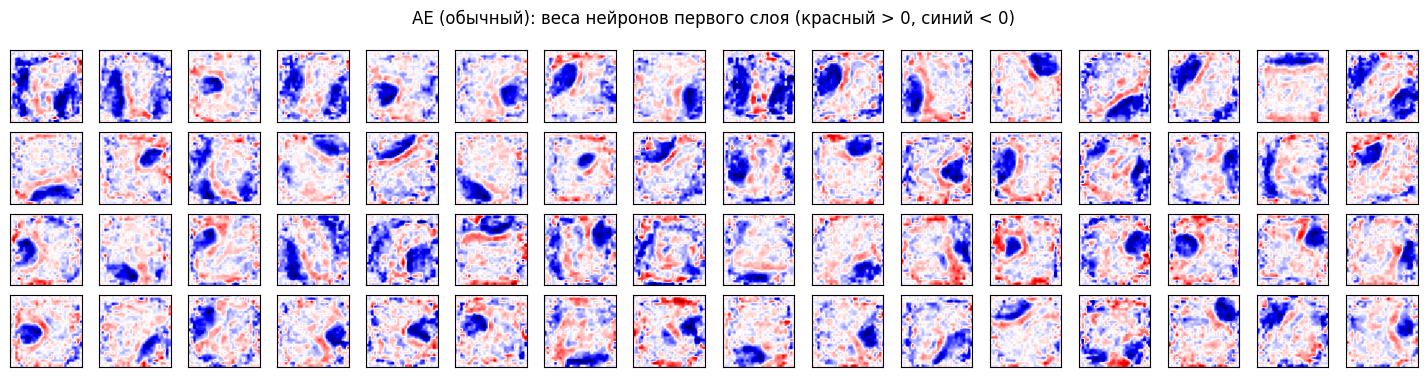

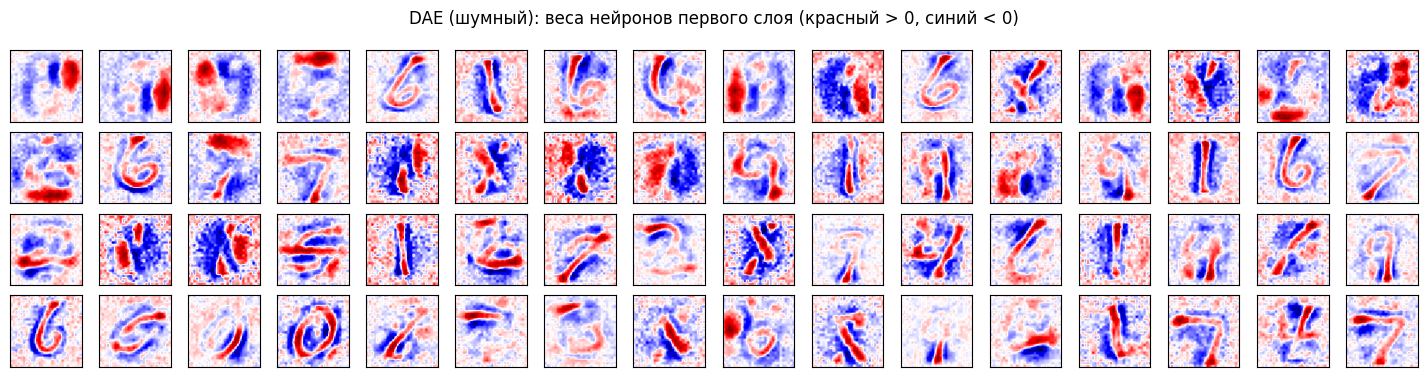

In [11]:
def plot_first_layer_weights(model, title, n=64, ncols=16):
    W = model.encoder[0].weight.detach()                     # [512, 784]
    order = W.norm(dim=1).argsort(descending=True)[:n]
    fig, axes = plt.subplots(n // ncols, ncols, figsize=(ncols * 0.9, n // ncols * 0.95))
    for ax, j in zip(axes.flat, order):
        w = W[j].view(28, 28).cpu()
        m = w.abs().max()
        ax.imshow(w, cmap='seismic', vmin=-m, vmax=m); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

plot_first_layer_weights(ae, 'AE (обычный): веса нейронов первого слоя (красный > 0, синий < 0)')
plot_first_layer_weights(dae, 'DAE (шумный): веса нейронов первого слоя (красный > 0, синий < 0)')

In [12]:
def activation_stats(model):
    with torch.no_grad():
        a = model.first_layer(X_test)
    dead = (a.max(0).values == 0).float().mean().item()      # нейроны, не активные ни на одном тестовом изображении
    active = (a > 0).float().mean().item()                   # доля активных нейронов на одно изображение
    return dead, active

for m, name in [(ae, 'AE'), (dae, 'DAE')]:
    dead, active = activation_stats(m)
    print(f'{name:4s} «мёртвых» нейронов первого слоя: {100*dead:4.1f}% | '
          f'в среднем активно нейронов на изображение: {100*active:4.1f}%')

AE   «мёртвых» нейронов первого слоя: 11.9% | в среднем активно нейронов на изображение: 54.8%
DAE  «мёртвых» нейронов первого слоя: 29.5% | в среднем активно нейронов на изображение: 18.3%


Разница между моделями хорошо видна (ср. с рисунками в статье Vincent et al.):
- веса **обычного АЕ** — крупные размытые «пятна» (как правило, тормозящие, синие) и зашумлённый фон. Каждый нейрон реагирует на яркость в какой-то области, почти не завися от формы штриха. Для копирования чистого входа этого достаточно: информация распределена по многим нейронам (плотный код);
- веса **шумного АЕ** — чёткие **детекторы штрихов**: вертикальные и наклонные палочки с тормозящей «обкладкой» по бокам (детектор линии/края), дуги, петли, а у многих нейронов — почти целые шаблоны цифр (6, 7, 0, 1, 9). Такой фильтр суммирует яркость вдоль всего штриха, поэтому независимый пиксельный шум при суммировании усредняется, а отклик на настоящий штрих остаётся сильным;
- код первого слоя DAE гораздо **разреженнее**: на изображение в среднем активно ~18% нейронов против ~55% у обычного АЕ, и почти 30% нейронов DAE вообще не активируются на тестовых данных. Каждый нейрон стал селективным детектором «своего» паттерна. Мёртвые нейроны сохраняют почти случайные веса, поэтому их и не видно среди 64 нейронов с наибольшей нормой.

### 5.2 Отклик нейронов на конкретное изображение
Берём одно тестовое изображение, его искажённую версию, и для 8 наиболее активных на чистом изображении нейронов DAE рисуем карту вклада $w_j \odot x$ (сумма карты + $b_j$ = активация до ReLU).

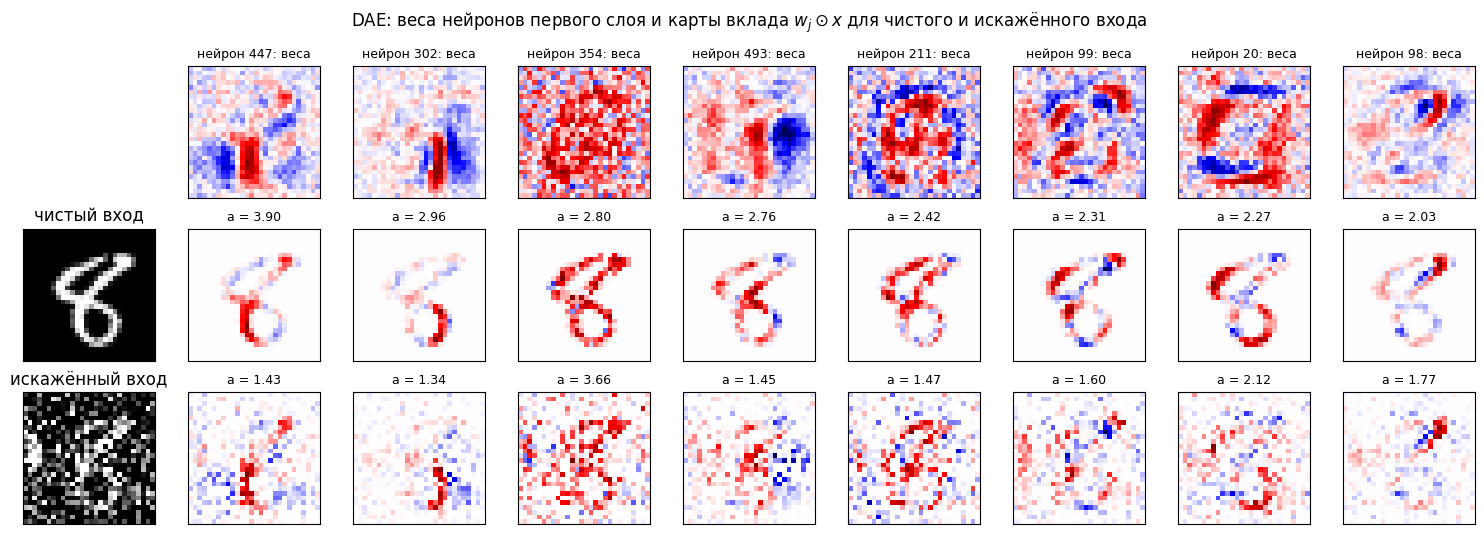

In [13]:
torch.manual_seed(3)
k = first_idx(8, 1)
x = X_test[k:k + 1]; xc = corrupt(x)
W, b = dae.encoder[0].weight.detach(), dae.encoder[0].bias.detach()
with torch.no_grad():
    a_clean, a_corr = dae.first_layer(x)[0], dae.first_layer(xc)[0]
top = a_clean.argsort(descending=True)[:8]

fig, axes = plt.subplots(3, 9, figsize=(15, 5.4))
axes[1, 0].imshow(x.view(28, 28).cpu(), cmap='gray'); axes[1, 0].set_title('чистый вход')
axes[2, 0].imshow(xc.view(28, 28).cpu(), cmap='gray'); axes[2, 0].set_title('искажённый вход')
axes[0, 0].axis('off')
for c, j in enumerate(top, start=1):
    w = W[j].view(28, 28).cpu(); m = w.abs().max()
    axes[0, c].imshow(w, cmap='seismic', vmin=-m, vmax=m); axes[0, c].set_title(f'нейрон {j.item()}: веса', fontsize=9)
    for r, (inp, act) in [(1, (x, a_clean)), (2, (xc, a_corr))]:
        contrib = (W[j] * inp[0]).view(28, 28).cpu(); mm = contrib.abs().max()
        axes[r, c].imshow(contrib, cmap='seismic', vmin=-mm, vmax=mm)
        axes[r, c].set_title(f'a = {act[j].item():.2f}', fontsize=9)
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('DAE: веса нейронов первого слоя и карты вклада $w_j \\odot x$ для чистого и искажённого входа'); plt.tight_layout(); plt.show()

Вклад в активацию дают пиксели, где штрих цифры совпадает с «красной» областью весов нейрона, а «синие» области подавляют нейрон, если там есть штрих. Нейроны-детекторы штрихов (447, 302, 493) на чистой «8» срабатывают на соответствующие участки петель. На искажённом входе их активация падает примерно в 2–3 раза, но не исчезает: вклады шума разного знака частично гасят друг друга, а отклик на реальный штрих сохраняется. Выделяется нейрон с почти целиком положительными «шумными» весами: он по сути измеряет общую яркость картинки и на шумном входе реагирует даже сильнее. Одного первого слоя для инвариантности недостаточно, она собирается глубже (см. 5.3).



### 5.3 Активации всех нейронов первого слоя: чистый vs искажённый вход
Рисуем вектор 512 активаций как карту 16×32 для нескольких изображений и обеих моделей.

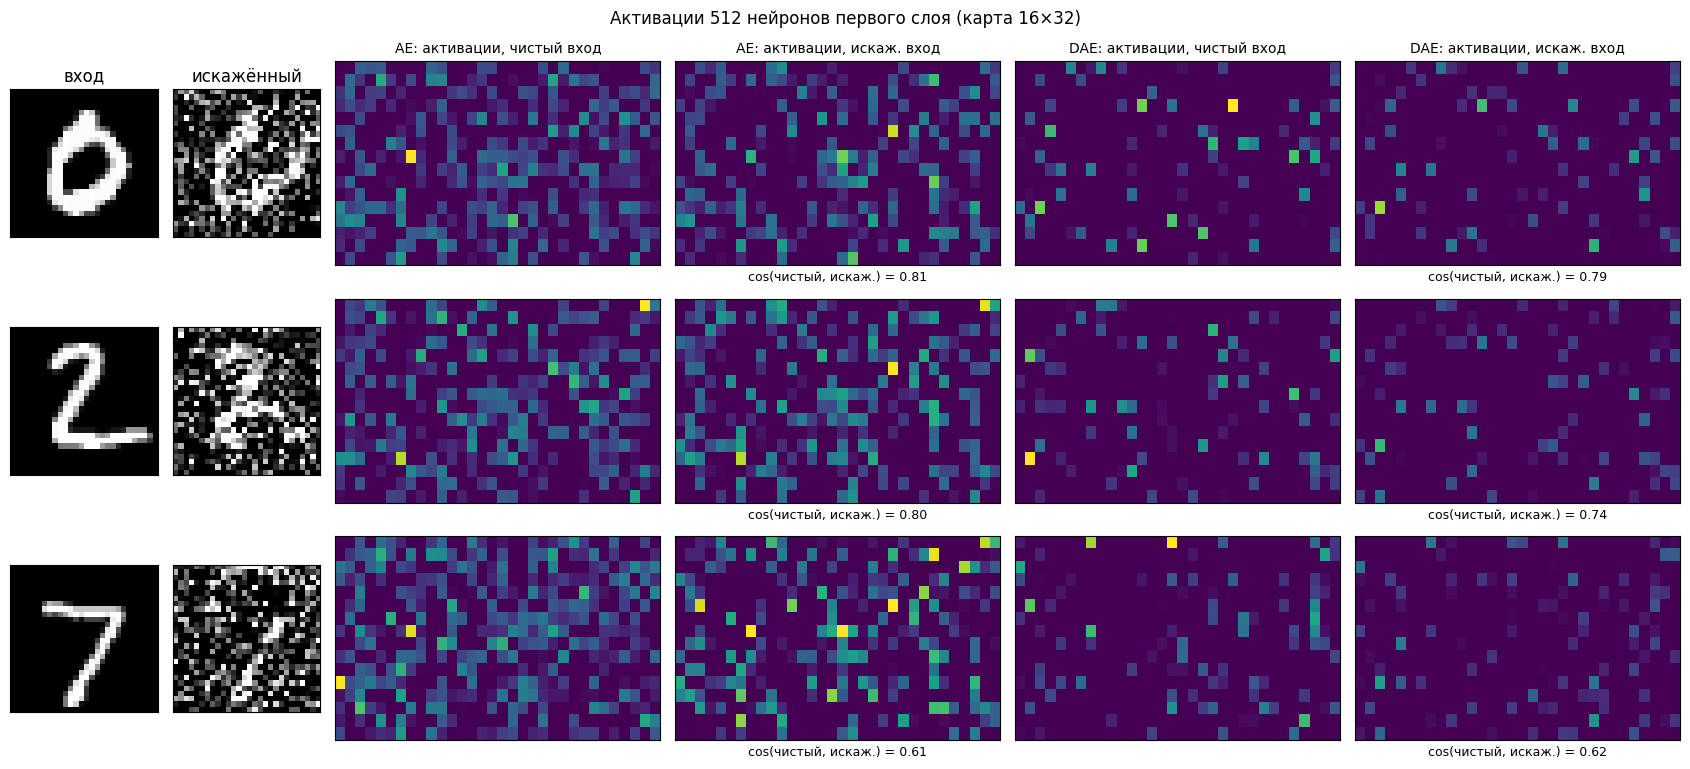

cos(чистый, искажённый)     слой 1 (512)  слой 2 (256)  латент (32)
AE                                 0.756         0.873        0.674
DAE                                0.711         0.894        0.882


In [14]:
torch.manual_seed(5)
ids = [first_idx(c) for c in (0, 2, 7)]
x = X_test[ids]; xc = corrupt(x)
fig, axes = plt.subplots(len(ids), 6, figsize=(17, 2.6 * len(ids)),
                         gridspec_kw={'width_ratios': [1, 1, 2.2, 2.2, 2.2, 2.2]})
with torch.no_grad():
    acts = {name: (m.first_layer(x), m.first_layer(xc)) for m, name in [(ae, 'AE'), (dae, 'DAE')]}
for i in range(len(ids)):
    axes[i, 0].imshow(x[i].view(28, 28).cpu(), cmap='gray'); axes[i, 1].imshow(xc[i].view(28, 28).cpu(), cmap='gray')
    col = 2
    for name in ['AE', 'DAE']:
        ac, acc_ = acts[name][0][i], acts[name][1][i]
        vmax = ac.max().item()
        for a, lbl in [(ac, 'чистый'), (acc_, 'искаж.')]:
            axes[i, col].imshow(a.view(16, 32).cpu(), cmap='viridis', vmin=0, vmax=vmax, aspect='auto')
            if i == 0: axes[i, col].set_title(f'{name}: активации, {lbl} вход', fontsize=10)
            col += 1
        cos = F.cosine_similarity(ac, acc_, dim=0).item()
        axes[i, col - 1].set_xlabel(f'cos(чистый, искаж.) = {cos:.2f}', fontsize=9)
axes[0, 0].set_title('вход'); axes[0, 1].set_title('искажённый')
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Активации 512 нейронов первого слоя (карта 16×32)'); plt.tight_layout(); plt.show()

@torch.no_grad()
def layerwise_similarity(model, x, xc):
    # cos-близость представлений чистого и искажённого входа после каждого слоя энкодера
    sims, h, hc = [], x, xc
    for layer in model.encoder:
        h, hc = layer(h), layer(hc)
        if not isinstance(layer, nn.Linear) or layer is model.encoder[-1]:
            sims.append(F.cosine_similarity(h, hc, dim=1).mean().item())
    return sims

print(f'{"cos(чистый, искажённый)":26s} {"слой 1 (512)":>13s} {"слой 2 (256)":>13s} {"латент (32)":>12s}')
for m, name in [(ae, 'AE'), (dae, 'DAE')]:
    s1, s2, s3 = layerwise_similarity(m, X_test, Xc_test)
    print(f'{name:26s} {s1:13.3f} {s2:13.3f} {s3:12.3f}')

Карты активаций хорошо показывают **разреженность**. У обычного АЕ на любую цифру откликается больше половины нейронов первого слоя, у шумного — лишь небольшой набор «своих» детекторов, причём для разных цифр набор разный.

А вот насчёт инвариантности результат интересный и не вполне очевидный: на **первом** слое DAE сходство представлений чистого и искажённого входа *не выше*, чем у обычного АЕ. Один линейный слой с ReLU не может убрать шум σ=0.5: сигнал ослабевает, часть детекторов гаснет, а в разреженном коде каждое такое выключение сильно меняет косинус. Инвариантность **нарастает с глубиной**: у DAE сходство растёт от слоя к слою и в латентном слое заметно выше, чем у обычного АЕ (0.88 против 0.67). У обычного АЕ оно на втором слое растёт, но в латентном слое резко падает: его латентный код кодирует искажение вместе с цифрой. Первый слой DAE извлекает устойчивые признаки-штрихи, а следующие слои собирают из них ответ на вопрос «какая это цифра», отбрасывая шум.

## 6. Выводы

**Как работает шумный автокодировщик.** На вход подаётся искажённое изображение (гауссовский шум σ=0.5 + зеркально отражённый фрагмент), а восстанавливать нужно чистое. Из-за этого тождественное отображение перестаёт быть решением, и сеть вынуждена выучить структуру данных — многообразие «правильных» цифр — и проецировать на него испорченные входы.

**Результаты сравнения обычного и шумного АЕ одинаковой архитектуры (784→512→256→32):**

| MSE на тесте | AE | DAE |
|---|---|---|
| чистый вход | ≈0.006 | ≈0.019 |
| шум σ=0.5 | ≈0.088 | ≈0.019 |
| отражение фрагмента | ≈0.040 | ≈0.027 |
| отражение + шум | ≈0.101 | ≈0.027 |

- На чистых данных обычный АЕ восстанавливает точнее. На искажённых он проигрывает шумному почти в 4 раза и выдаёт размытые пятна. DAE полностью убирает шум и в большинстве случаев достраивает правильную форму цифры на месте отражённого фрагмента.
- **Латентное представление DAE** хранит прежде всего класс и общую форму цифры (наклон, толщину, стиль штриха) и устойчиво к искажениям. Код искажённого изображения близок к коду чистого (cos ≈0.88 против ≈0.67). Линейный классификатор, обученный на кодах чистых изображений, на искажённых даёт ~59% точности против ~23% у обычного АЕ. Кластеры классов на t-SNE после искажения у DAE сохраняются, а у обычного АЕ полностью разрушаются. Индивидуальные детали конкретного экземпляра при таком сильном шуме теряются.
- Латентное пространство гладкое: интерполяция между кодами двух цифр даёт последовательность правдоподобных цифр, а не наложение изображений.
- **Карты весов первого слоя** DAE — детекторы штрихов, дуг и шаблонов цифр с тормозящим окружением, а у обычного АЕ — размытые пятна. Код первого слоя DAE в ~3 раза разреженнее. Инвариантность к искажениям на первом слое ещё не появляется и нарастает с глубиной сети.

Итого: шум во входе работает как регуляризатор, который заставляет автокодировщик извлекать устойчивые, осмысленные признаки. Эта же идея — обучать сеть убирать шум — лежит в основе диффузионных моделей (задание 1), где денойзер обучается сразу на всех уровнях шума.